Setup and Clone

In [3]:
import os

%cd /content

repo_name = "Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual"
if not os.path.exists(repo_name):
  !git clone https://github.com/ayiii-a/Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual.git


%cd /content/{repo_name}

from google.colab import drive
drive.mount('/content/drive')

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

!pip install -q transformers accelerate

/content
/content/Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Loading and Distribution Visualization

start loading TweepFake data...
Train size: 20712 | Test size: 2558


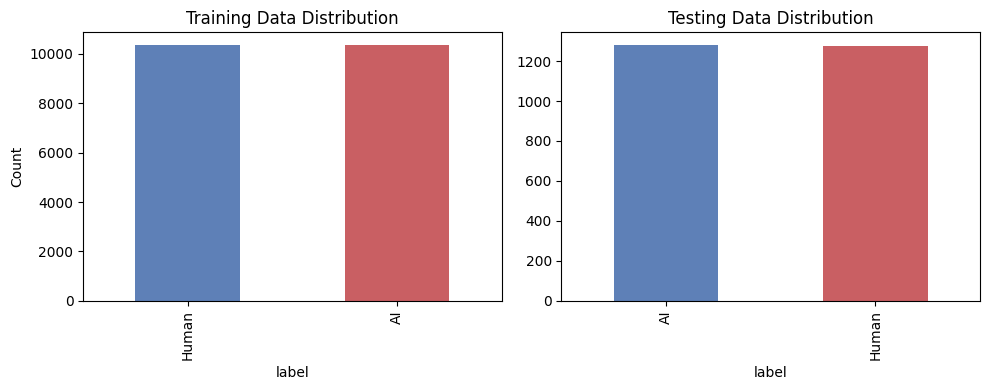

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load TweepFake data (use ';' separator)
print("start loading TweepFake data...")
train_df = pd.read_csv("./data/train.csv", sep=';')
test_df = pd.read_csv("./data/test.csv", sep=';')

train_df.rename(columns={'text': 'Text'}, inplace=True)
test_df.rename(columns={'text': 'Text'}, inplace=True)

# map labels (Human=0, Bot=1)
label_map = {"human": 0, "bot": 1}
train_df['label'] = train_df['account.type'].str.lower().map(label_map)
test_df['label'] = test_df['account.type'].str.lower().map(label_map)

# clean missing values
train_df = train_df[['Text', 'label']].dropna()
test_df = test_df[['Text', 'label']].dropna()

# extract arrays
X_train, y_train = train_df['Text'].values, train_df['label'].values
X_test, y_test = test_df['Text'].values, test_df['label'].values

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# VISUALIZATION 1: Data Distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# train plot
train_counts = train_df['label'].value_counts().rename(index={0: 'Human', 1: 'AI'})
train_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'], alpha=0.9)
axes[0].set_title('Training Data Distribution')
axes[0].set_ylabel('Count')

# test plot
test_counts = test_df['label'].value_counts().rename(index={0: 'Human', 1: 'AI'})
test_counts.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#C44E52'], alpha=0.9)
axes[1].set_title('Testing Data Distribution')

plt.tight_layout()
plt.show()

RoBERTa Tokenizer and DataLoader

In [5]:
import torch
import re
import numpy as np
from transformers import AutoTokenizer
from torch.utils.data import DataLoader, TensorDataset

def preprocess_for_transformer(texts, tokenizer, max_len=128):
    encoded = tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    # return ids and attention masks
    return encoded['input_ids'], encoded['attention_mask']

# feature extraction
def extract_stylo_features(text):
    text = str(text)
    chars = len(text) + 1
    words = text.split()
    word_cnt = len(words) + 1

    avg_word_len = sum(len(w) for w in words) / word_cnt
    caps_ratio = sum(1 for c in text if c.isupper()) / chars
    punc_ratio = len(re.findall(r'[!?.]', text)) / chars
    hashtag_density = text.count('#') / word_cnt
    mention_density = text.count('@') / word_cnt
    url_flag = 1.0 if 'http' in text.lower() else 0.0
    lexical_richness = len(set(words)) / word_cnt

    return [avg_word_len, caps_ratio, punc_ratio, hashtag_density, mention_density, url_flag, lexical_richness]

# tensors
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("extracting stylometrics and tokenizing...")
train_ids, train_masks = preprocess_for_transformer(X_train, tokenizer)
test_ids, test_masks = preprocess_for_transformer(X_test, tokenizer)

stylo_train = torch.tensor([extract_stylo_features(t) for t in X_train], dtype=torch.float)
stylo_test = torch.tensor([extract_stylo_features(t) for t in X_test], dtype=torch.float)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# DataLoaders
train_loader = DataLoader(
    TensorDataset(train_ids, train_masks, stylo_train, y_train_tensor),
    batch_size=32, shuffle=True
)
eval_loader = DataLoader(
    TensorDataset(test_ids, test_masks, stylo_test, y_test_tensor),
    batch_size=32, shuffle=False
)
print("DataLoaders ready...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


extracting stylometrics and tokenizing...
DataLoaders ready...


Transformer Fine-tuning Loop with **MODEL OPTIONS**

In [6]:
import torch.nn as nn
from transformers import AutoModel
from torch.optim import AdamW

# chose MODEL OPTIONS here

# 'base' | 'mean_pooling'
MODEL_MODE = 'mean_pooling'
# True | False
USE_STYLO = True
# # of features in extract_stylo_features(last cell)
STYLO_DIM = 7

class HybridSemanticRoBERTa(nn.Module):
    def __init__(self, mode='base', use_stylo=False, stylo_dim=7):
        super(HybridSemanticRoBERTa, self).__init__()
        self.mode = mode
        self.use_stylo = use_stylo
        self.roberta = AutoModel.from_pretrained("roberta-base")

        # input dimension
        # 768 (RoBERTa) + stylometrics
        self.input_dim = 768 + (stylo_dim if use_stylo else 0)

        self.classifier = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, stylo_feats):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state

        # if pool
        if self.mode == 'base':
            pooled = last_hidden[:, 0, :]
        else:
            mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
            sum_embeddings = torch.sum(last_hidden * mask, 1)
            sum_mask = torch.clamp(mask.sum(1), min=1e-9)
            pooled = sum_embeddings / sum_mask

        # if stylometrics
        if self.use_stylo:
            final_features = torch.cat((pooled, stylo_feats), dim=1)
        else:
            final_features = pooled

        return self.classifier(final_features)

# init model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HybridSemanticRoBERTa(mode=MODEL_MODE, use_stylo=USE_STYLO).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# training Loop
print(f"running: [Mode: {MODEL_MODE}] [Stylo: {USE_STYLO}] on {device}...")
for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        b_ids, b_masks, b_stylo, b_labels = [t.to(device) for t in batch]
        optimizer.zero_grad()
        logits = model(b_ids, b_masks, b_stylo)
        loss = criterion(logits, b_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1}, loss: {total_loss/len(train_loader):.4f}")

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


running: [Mode: mean_pooling] [Stylo: True] on cuda...
epoch 1, loss: 0.2945
epoch 2, loss: 0.1895
epoch 3, loss: 0.1216


Evaluation

start evaluation on test set [Mode: mean_pooling] [Stylo: True]...

-------------------------------------------------------
STRATEGY A: HIGH PRECISION (Threshold 0.5)
Goal: minimal false bans of human accounts
-------------------------------------------------------
AUC-ROC:   0.9744
F1-Score:  0.9136
Precision: 0.9140
Recall:    0.9133

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       0.91      0.91      0.91      1278
      AI (1)       0.91      0.91      0.91      1280

    accuracy                           0.91      2558
   macro avg       0.91      0.91      0.91      2558
weighted avg       0.91      0.91      0.91      2558


-------------------------------------------------------
STRATEGY B: HIGH RECALL (Threshold 0.1)
Goal: catch maximum potential AI accounts
-------------------------------------------------------
AUC-ROC:   0.9744
F1-Score:  0.9066
Precision: 0.8537
Recall:    0.9664

Detailed Report:
              precision    recal

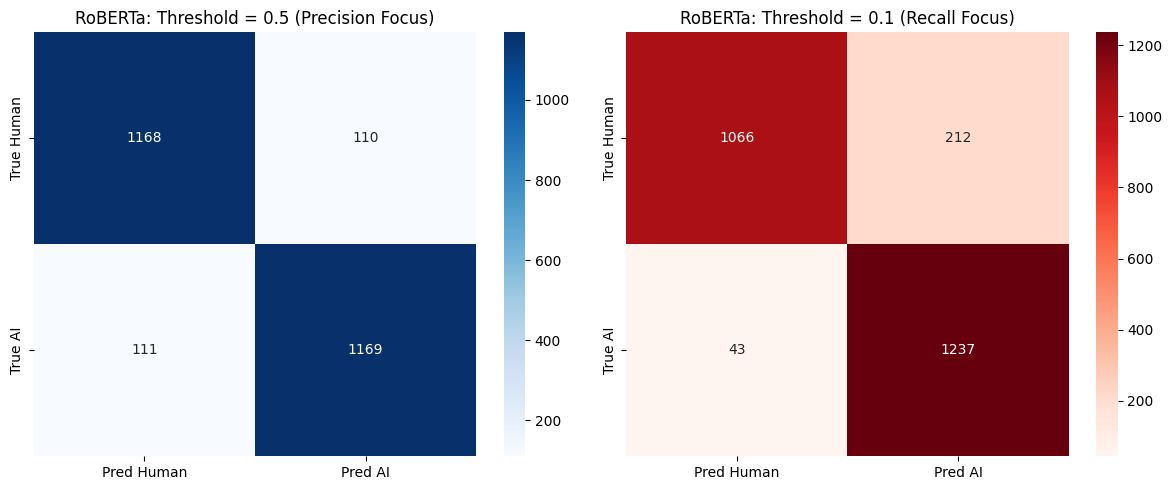

In [7]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, classification_report, confusion_matrix

model.eval()
all_probs = []

print(f"start evaluation on test set [Mode: {MODEL_MODE}] [Stylo: {USE_STYLO}]...")

with torch.no_grad():
    for batch in eval_loader:
        b_input_ids, b_input_mask, b_stylo, _ = [t.to(device) for t in batch]
        outputs = model(b_input_ids, b_input_mask, b_stylo)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())

all_probs = torch.tensor(all_probs)
y_test_tensor = y_test_tensor.cpu()
global_auc = roc_auc_score(y_test_tensor, all_probs)

# EVALUATION A: High Precision (Threshold 0.5)
thresh_A = 0.5
preds_A = (all_probs > thresh_A).long()
cm_A = confusion_matrix(y_test_tensor, preds_A)

print("\n" + "-"*55)
print(f"STRATEGY A: HIGH PRECISION (Threshold {thresh_A})")
print("Goal: minimal false bans of human accounts")
print("-" * 55)
print(f"AUC-ROC:   {global_auc:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor, preds_A):.4f}")
print(f"Precision: {precision_score(y_test_tensor, preds_A):.4f}")
print(f"Recall:    {recall_score(y_test_tensor, preds_A):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor, preds_A, target_names=['Human (0)', 'AI (1)']))

# EVALUATION B: High Recall (Threshold 0.1)
thresh_B = 0.1
preds_B = (all_probs > thresh_B).long()
cm_B = confusion_matrix(y_test_tensor, preds_B)

print("\n" + "-"*55)
print(f"STRATEGY B: HIGH RECALL (Threshold {thresh_B})")
print("Goal: catch maximum potential AI accounts")
print("-" * 55)
print(f"AUC-ROC:   {global_auc:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor, preds_B):.4f}")
print(f"Precision: {precision_score(y_test_tensor, preds_B):.4f}")
print(f"Recall:    {recall_score(y_test_tensor, preds_B):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor, preds_B, target_names=['Human (0)', 'AI (1)']))

# VISUALIZATION: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
axes[0].set_title(f'RoBERTa: Threshold = {thresh_A} (Precision Focus)')

sns.heatmap(cm_B, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
axes[1].set_title(f'RoBERTa: Threshold = {thresh_B} (Recall Focus)')

plt.tight_layout()
plt.show()